# OpenUniverse — error de observación Roman desde el SED (`galsim.roman`)

Toma la magnitud verdadera por banda de un transiente del `snana_<healpix>.hdf5` de OpenUniverse
(`mag_<R,Z,Y,J,H,F,K>` sobre la grilla `mjd` del modelo), la **muestrea a la cadencia real del survey**
(HLTDS Wide/Deep, nearest-MJD) y le estima el **error fotométrico por época** con la receta de ruido de
`galsim.roman` (sky + thermal + dark + read sobre la NEA del PSF, más el Poisson de la fuente).
De ahí salen SNR, barra de error y el flag de detección S/N ≥ 5.

El hdf5 **no** trae error/NEA/flux-calib: todo eso se deriva acá desde `galsim.roman`. Es la misma
receta validada en `openuniverse_route_a_lightcurves.ipynb`, aquí aplicada a la curva verdadera del SED.

Parámetros clave en la celda de setup: `TIER` ("wide"/"deep") fija filtros, exposición total por época
(`EXPOSURE_TIME`) y cadencia (`CADENCE_DAYS`). El criterio del pipeline son las **primeras 4 épocas
desde la primera detección S/N ≥ 5**.


In [1]:
from kilonova.config import load_paths

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import galsim
import galsim.roman as roman

# Receta de error fotométrico Roman (fuente única de verdad): constantes y funciones se importan de
# roman_photometry.py en vez de redefinirlas aquí, para no desincronizar las 3 copias del pipeline.
from kilonova.photometry.roman_noise import (
    SNR_DETECTION, ZP_JITTER_SIGMA,
    EXPOSURE_TIME_BY_TIER, BASE_CADENCE_DAYS, TIER_ANCHOR_BAND, ALL_BANDS_BY_WAVELENGTH,
    HLTDS_FIELD_CENTER, HLTDS_FIELDS_BY_TIER,
    field_center_for_tier, cadence_schedule,
)

# Para esta validación el hdf5 ya está descargado en el scratchpad de la sesión.
# En la corrida por healpix será openuniverse_cache/snana_<healpix>.hdf5.
HDF5_PATH = str(load_paths().openuniverse_hdf5)
CATALOG_PATH = str(load_paths().openuniverse_catalog)

# Las constantes del survey (exposición por tier/época, cadencia, campos HLTDS, mapeo HLTDS->galsim,
# elección aleatoria de campo) viven en roman_photometry.py — ver ahí la documentación de cada una.

TIER = "deep"  # "wide" | "deep" — define filtros, exposición y cadencia
EXPOSURE_TIME = EXPOSURE_TIME_BY_TIER[TIER]
ANCHOR_BAND = TIER_ANCHOR_BAND[TIER]
# Campo del tier: elección aleatoria entre los campos válidos, semilla fija -> reproducible por corrida.
FIELD_SEED = 0
FIELD_NAME, FIELD_CENTER_RA, FIELD_CENTER_DEC = field_center_for_tier(TIER, np.random.default_rng(FIELD_SEED))

# Bandas del tier, ordenadas por longitud de onda. La letra del hdf5 (mag_<X>) es la inicial de la banda.
BANDS_BY_WAVELENGTH = [band for band in ALL_BANDS_BY_WAVELENGTH if band in EXPOSURE_TIME]

# Cadencia efectiva por banda (referencia / zoom): anchor cada 5 d, las otras cada 10 d.
CADENCE_DAYS = {band: (BASE_CADENCE_DAYS if band == ANCHOR_BAND else 2 * BASE_CADENCE_DAYS)
                for band in BANDS_BY_WAVELENGTH}

BAND_WAVELENGTH_MICRON = {"R062": 0.62, "Z087": 0.87, "Y106": 1.06, "J129": 1.29,
                          "H158": 1.58, "F184": 1.84, "K213": 2.13}
# Paleta idéntica a roman_filter_transmissions (Extinction.ipynb) y a BAND_COLORS: turbo muestreado
# uniforme sobre las bandas Roman ordenadas por longitud de onda. Color FIJO por banda, independiente
# del tier, para que cada filtro sea el mismo color en todas las figuras del paper (así Z087 y Y106 no
# colisionan como con el mapeo por micras).
ROMAN_BANDS_BY_WAVELENGTH = ["R062", "Z087", "Y106", "J129", "H158", "F184"]
BAND_COLOR = {band: plt.cm.turbo(position)
              for band, position in zip(ROMAN_BANDS_BY_WAVELENGTH,
                                        np.linspace(0.05, 0.95, len(ROMAN_BANDS_BY_WAVELENGTH)))}

GENTYPE_LABEL = {10: "SN Ia", 12: "SN Iax", 21: "SN Ib", 26: "SN Ic", 32: "SN II",
                 40: "SLSN-I", 42: "TDE", 50: "KN", 57: "PISN-H", 58: "PISN-He", 99: "FIXMAG"}

# Fila de cuadrados de cadencia: OFFSET = mag por encima (más brillante) de la magnitud más brillante
# mostrada; STEP = escalón entre bandas para que dos cuadrados de la misma época no se superpongan.
CADENCE_ROW_OFFSET_MAG = 0.5
CADENCE_ROW_STEP_MAG = 0.13


def plot_lightcurve_with_error(photometry, title="", ax=None, marker_scale=1.0, reference_magnitude=None):
    own_axis = ax is None
    if own_axis:
        figure, ax = plt.subplots(figsize=(9, 5))
    # Eje de tiempo unificado con el pipeline y el dataloader: días desde la 1ª detección S/N>=5.
    present_bands = [band for band in BANDS_BY_WAVELENGTH if (photometry["band"] == band).any()]
    # Cada visita (cada 5 d) observa 3 de los 5 filtros del tier; los 2 NO observados se marcan con un
    # cuadrado (arriba). Así cada época muestra siempre 5 símbolos = los 5 filtros del tier:
    # 3 con dato (○ detección / ▽ límite) + 2 cuadrados (no observado en esa visita). Valida la cadencia.
    base_visits = np.sort(photometry["days_since_detection"].unique())
    # Fila de cadencia (cuadrados "not observed") en coordenadas de DATOS, CADENCE_ROW_OFFSET_MAG por encima
    # de la magnitud más brillante MOSTRADA (reference_magnitude; el que llama la pasa según su zoom, así no
    # queda fuera del ylim). Cada banda va en su propia sub-fila (escalón CADENCE_ROW_STEP_MAG) para que dos
    # cuadrados de la misma época no se tapen entre sí.
    if reference_magnitude is not None and np.isfinite(reference_magnitude):
        brightest_magnitude = reference_magnitude
    else:
        brightest_magnitude = photometry.loc[photometry["detected"], "mag_observed"].min()
        if not np.isfinite(brightest_magnitude):
            brightest_magnitude = photometry["mag_true"].min()
    bands_with_gap = [band for band in present_bands
                      if len(np.setdiff1d(base_visits,
                                          photometry.loc[photometry["band"] == band,
                                                         "days_since_detection"].to_numpy())) > 0]
    cadence_step = CADENCE_ROW_STEP_MAG * marker_scale
    cadence_row_by_band = {band: brightest_magnitude - CADENCE_ROW_OFFSET_MAG - position * cadence_step
                           for position, band in enumerate(bands_with_gap)}
    # Magnitud del escalón más alto (más brillante) -> el que llama la usa para dejar aire en el ylim.
    ax._cadence_top_magnitude = (min(cadence_row_by_band.values()) if cadence_row_by_band
                                 else brightest_magnitude - CADENCE_ROW_OFFSET_MAG)
    for band in present_bands:
        band_rows = photometry[photometry["band"] == band]
        color = BAND_COLOR[band]
        detections = band_rows[band_rows["detected"]]
        upper_limits = band_rows[~band_rows["detected"]]
        if len(detections) > 0:
            ax.errorbar(detections["days_since_detection"], detections["mag_observed"], yerr=detections["mag_err"],
                        fmt="o", ms=4 * marker_scale, color=color, ecolor=color, elinewidth=0.6,
                        capsize=0, mec="k", mew=0.3)
        if len(upper_limits) > 0:
            ax.scatter(upper_limits["days_since_detection"], upper_limits["mag_limit_5sigma"], marker="v",
                       s=22 * marker_scale ** 2, color=color, edgecolor="k", linewidth=0.3, alpha=0.45)
        not_observed = np.setdiff1d(base_visits, band_rows["days_since_detection"].to_numpy())
        if len(not_observed) > 0:
            # Cuadrados del mismo tamaño que círculos/triángulos, en la sub-fila de la banda.
            ax.scatter(not_observed, np.full(len(not_observed), cadence_row_by_band[band]), marker="s",
                       s=22 * marker_scale ** 2, color=color, edgecolor="k", linewidth=0.3, alpha=0.9, zorder=4)

    first = photometry[photometry["detected"]]["days_since_detection"]
    if len(first) > 0:
        ax.axvline(first.min(), color="grey", ls=":", lw=1.0)
    ax.invert_yaxis()
    ax.set_xlabel("Days since first detection")
    ax.set_ylabel("AB mag")
    ax.set_title(title)
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both", top=True, right=True)
    band_handles = [plt.Line2D([], [], marker="o", ls="", color=BAND_COLOR[band], mec="k", mew=0.3, label=band)
                    for band in present_bands]
    symbol_handles = [plt.Line2D([], [], marker="o", ls="", color="0.4", label="detection (S/N≥5)"),
                      plt.Line2D([], [], marker="v", ls="", color="0.4", label="limit 5σ"),
                      plt.Line2D([], [], marker="s", ls="", color="0.4", label="not observed (cadence)")]
    # Leyenda fuera del área de datos (columna derecha) para que no tape la curva. Los que llaman a esta
    # función reservan el margen derecho con subplots_adjust(right=0.80) en vez de tight_layout.
    ax.legend(handles=band_handles + symbol_handles, fontsize=7, ncol=1,
              loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False,
              handletextpad=0.4, labelspacing=0.5, borderaxespad=0.0)
    if own_axis:
        figure.subplots_adjust(right=0.80)
        plt.show()


## La receta de ruido — la idea de Hourglass aplicada a OpenUniverse

El error fotométrico de cada época sale de **una sola ecuación**: la ecuación CCD estándar
(Howell 1989, eq. 14), la misma con la que reproducimos el `fluxcal_err` de Hourglass (mediana
$\sigma_{\text{pred}}/\sigma_{\text{real}}=0.986$). En espacio de cuentas (electrones), la varianza
de una medición de fuente puntual es

$$\sigma^2(F) \;=\; \underbrace{F_{\text{fuente}}}_{\text{Poisson de la fuente}} \;+\; \underbrace{n_{\text{pix}}\,\big(B_{\text{sky}} + B_{\text{thermal}} + B_{\text{dark}} + \sigma_{\text{read}}^2\big)}_{\text{fondo + lectura}} \qquad [e^{-2}]$$

con $n_{\text{pix}} = \mathrm{NEA}$, el **número equivalente de píxeles** de la PSF (King 1983; Naylor 1998
para extracción óptima). Esto es exactamente lo que implementan las dos celdas siguientes:
`NOISE_FLOOR_VARIANCE` es el segundo término (el fondo, fijo por banda) y `flux_electrons` es el primero.

### Por qué es "la misma idea" que Hourglass, pero más limpia

Hourglass entrega su fotometría en `fluxcal` (convención SNANA, ZP=27.5), así que su receta tiene que
**puentear** cuentas físicas ↔ `fluxcal` con el factor $\text{flux\_calibrated}(zp)=10^{(27.5-zp)/2.5}$:

| | término de fuente | término de fondo |
|---|---|---|
| **Hourglass** (`fluxcal`) | $\text{flux\_calibrated}(zp)\cdot F_{\text{sim}}$ — lineal en el puente | $\mathrm{NEA}\,(\sigma_{\text{sky}}^2+\sigma_{\text{read}}^2)\cdot\text{flux\_calibrated}(zp)^2$ — **cuadrático** en el puente |
| **Este notebook** (`galsim.roman`, $e^-$) | $F_{\text{fuente}}$ — el conteo mismo | $\mathrm{NEA}\,(B_{\text{sky}}+B_{\text{thermal}}+B_{\text{dark}}+\sigma_{\text{read}}^2)$ |

La asimetría lineal/cuadrático de Hourglass es **sólo el cambio de unidades** $e^{-2}\to\text{fluxcal}^2$
(el término de fuente lleva un factor de Fano $\alpha$, el de fondo lleva $\alpha^2$ de propagación lineal).
Acá **nunca salimos de electrones**: la varianza Poisson de $N$ electrones *es* $N$, sin factor puente
y sin Fano explícito. Por eso `flux_error = np.sqrt(flux_electrons + noise_floor)` es la traducción
directa de la ecuación de arriba.

Ventaja práctica de quedarnos en `galsim.roman`: **cada número es trazable a su fuente** — `getSkyLevel`,
`thermal_backgrounds`, `dark_current`, el `zeropoint` AB del bandpass y la NEA salida de `getPSF`. El
único término que tomamos del paper (no de galsim) es el read noise, por la razón de abajo.

### Cómo entra el tiempo de exposición (los nuevos valores del HLTDS)

`EXPOSURE_TIME_BY_TIER` trae los tiempos **totales por época**. Cada término del fondo depende de la
exposición $t$, y eso está puesto en el cálculo de `NOISE_FLOOR_VARIANCE`:

- **sky, thermal, dark** → **crecen con $t$**: son tasas de electrones acumulando señal. `getSkyLevel(exptime=t)`,
  `thermal_backgrounds·t`, `dark_current·t`. Más exposición ⇒ más fondo acumulado.
- **read noise** → **decrece con $t$** (Rose et al. 2025, **eq. 9**), por el muestreo *up-the-ramp*:

$$\sigma_{\text{read}} = \sqrt{\;\sigma^2_{\text{floor}} + \sigma^2\,\frac{n-1}{n(n+1)}\;}, \qquad n = \frac{t_{\text{exp}}}{3.04\,\text{s}},\quad \sigma^2_{\text{floor}}=25,\quad \sigma^2 = 12\cdot 16^2 = 3072 \;\;[e^{-2}]$$

  Los detectores NIR de Roman se leen de forma **no-destructiva cada 3.04 s**, así que una época de
  $t_{\text{exp}}$ acumula $n=t_{\text{exp}}/3.04$ lecturas. Al ajustar la pendiente sobre $n$ lecturas el
  read noise efectivo **baja** (el término $\frac{n-1}{n(n+1)}\to\frac1n\to0$) y **satura en el piso**
  $\sqrt{25}=5\,e^-$. Con tus nuevos tiempos: ~5.5 $e^-$ (F184, 1636 s) hasta ~13 $e^-$ (R062, 60 s).

> **Cuidado con el denominador.** La eq. 9 lleva $n(n+1)$ en el denominador, **no** $(n+1)$. Verificación:
> F184 DEEP a la exposición vieja (900 s, $n=296$) da $\sqrt{25+3072\cdot 295/(296\cdot 297)}=\mathbf{5.94\,e^-}$,
> idéntico al Table 3 del paper (F = 5.942). Con $(n+1)$ a secas saldría ~55 $e^-$ (10× de más). Esto
> reemplaza al `roman.read_noise` estático de galsim, que desconoce los tiempos del HLTDS revisado.

### El NEA y el jitter del zeropoint (Hourglass eq. 8) — *modelado*

El NEA y el throughput **cambian con la posición en el plano focal**. En vez de variar la PSF fila por fila,
Hourglass **fija el NEA por banda** (mediana mejor/peor FOV, Table 3) y **absorbe** esa variación FOV-a-FOV
en un **scatter gaussiano de $\sigma=0.15$ mag sobre el zeropoint** de cada observación
($\text{ZP\_AVG} = \text{ZP} + 2.5\log_{10}t + \mathcal{N}(0,0.15)$). Replicamos exactamente eso:

- el NEA sale **una vez por banda** de `getPSF` en el centro del campo (decisión deliberada, igual que Hourglass);
- cada época recibe un **jitter** $\delta\sim\mathcal{N}(0,\texttt{ZP\_JITTER\_SIGMA})$, `ZP_JITTER_SIGMA=0.15 mag`,
  sumado a su zeropoint antes de convertir `mag_true → flux_electrons`. Un $\delta$ positivo = posición del FOV
  más sensible = más electrones = mayor SNR. La semilla del jitter se fija **por objeto** (reproducible) e
  independiente entre épocas/bandas (cada visita cae en otra parte del plano focal). `ZP_JITTER_SIGMA=0` lo apaga.

El jitter se aplica al zeropoint de la **fuente** (el término que mueve la SNR); el fondo en electrones
(`getSkyLevel` etc.) es absoluto y no depende de ese zeropoint, así que no se toca.


In [2]:
# Calibración Roman desde roman_photometry.py (que la deriva de galsim.roman): zeropoint AB, NEA,
# read noise eq.9 y el piso de ruido por banda. El hdf5 no aporta nada de esto. La constante
# ZP_JITTER_SIGMA y read_noise_electrons/PSF_NEA_PIX se importan; no se redefinen aquí.
from kilonova.photometry.roman_noise import (
    PSF_NEA_PIX, roman_zeropoint, collecting_area_cm2,
    read_noise_electrons, build_tier_constants,
    source_flux_electrons, flux_error_electrons, limiting_magnitude_5sigma,
)

# Constantes del tier (bandas, zeropoint, piso de ruido NEA-pesado) derivadas en el módulo a la
# exposición del TIER y el campo de FIELD_SEED. Es exactamente la misma receta del pipeline.
_tier_constants = build_tier_constants(TIER, field_seed=FIELD_SEED)
NOISE_FLOOR_VARIANCE = _tier_constants["noise_floor_variance"]
READ_NOISE_BY_BAND = {band: read_noise_electrons(EXPOSURE_TIME[band]) for band in BANDS_BY_WAVELENGTH}

pd.DataFrame({"read_noise_e": pd.Series(READ_NOISE_BY_BAND),
              "noise_floor_variance_e2": pd.Series(NOISE_FLOOR_VARIANCE)})


,read_noise_e,noise_floor_variance_e2
Z087,8.478636,1099.372099
Y106,7.490976,1652.906757
J129,7.404273,2009.190961
H158,6.849515,3162.985676
F184,5.539602,13208.567471


In [3]:
def read_true_lightcurve(object_id, hdf5=None, hdf5_path=HDF5_PATH):
    """Curva de luz verdadera (sin ruido) de un objeto: mag_<banda>(mjd) sobre TODA la grilla del
    modelo del hdf5, solo para las bandas del TIER, en formato largo. Descarta mag >= 99.
    La letra del dataset hdf5 (mag_R, mag_Z, ...) es la inicial de la banda galsim (R062 -> R).
    `hdf5` permite pasar un File ya abierto (para escanear muchos objetos sin reabrirlo)."""
    handle = hdf5 if hdf5 is not None else h5py.File(hdf5_path, "r")
    try:
        group = handle[str(object_id)]
        mjd = group["mjd"][:]
        rows = []
        for band in BANDS_BY_WAVELENGTH:
            magnitude = group["mag_" + band[0]][:]
            valid = np.isfinite(magnitude) & (magnitude < 99)
            rows.append(pd.DataFrame({"object_id": object_id, "mjd": mjd[valid],
                                      "band": band, "mag_true": magnitude[valid]}))
    finally:
        if hdf5 is None:
            handle.close()
    return pd.concat(rows, ignore_index=True)


def resample_to_cadence(true_lightcurve):
    """Pasa de la grilla densa del modelo a las ÉPOCAS DE OBSERVACIÓN del survey: visitas base cada
    BASE_CADENCE_DAYS sobre la ventana del modelo, repartidas por banda con roman_photometry.cadence_schedule
    (anchor en todas, las otras 4 en 2 pares intercalados). Toma la mag del MJD del modelo MÁS CERCANO
    (nearest, no interpola: la grilla <=1 d es mucho más fina que la cadencia 5-10 d). El MJD absoluto se
    mantiene solo como eje interno para el nearest-lookup; el eje de salida es days_since_detection."""
    window_start = true_lightcurve["mjd"].min()
    window_end = true_lightcurve["mjd"].max()
    base_epochs = np.arange(window_start, window_end + 1e-9, BASE_CADENCE_DAYS)
    schedule = cadence_schedule(base_epochs, BANDS_BY_WAVELENGTH, ANCHOR_BAND)
    rows = []
    for band in BANDS_BY_WAVELENGTH:
        band_rows = true_lightcurve[true_lightcurve["band"] == band]
        if len(band_rows) == 0:
            continue
        model_mjd = band_rows["mjd"].to_numpy()
        model_mag = band_rows["mag_true"].to_numpy()
        epochs = schedule[band]
        epochs = epochs[(epochs >= model_mjd.min()) & (epochs <= model_mjd.max())]
        nearest = np.abs(model_mjd[None, :] - epochs[:, None]).argmin(axis=1)
        rows.append(pd.DataFrame({"object_id": band_rows["object_id"].iloc[0],
                                  "mjd": epochs, "band": band, "mag_true": model_mag[nearest]}))
    return pd.concat(rows, ignore_index=True)


def estimate_observation_error(photometry, plot=False):
    """Estima el error fotométrico Roman de cada (época, banda) con la receta de roman_photometry:
    mag_true -> flux en electrones -> sigma_flux (Poisson fuente + piso de ruido NEA) -> SNR.
    Usa el tiempo de exposición TOTAL por época del tier (EXPOSURE_TIME). Agrega days_since_detection
    (cero en la 1ª detección S/N>=5; si no hay detección, relativo a la 1ª visita) como eje de tiempo,
    misma convención que el early_windows_{tier}.parquet del pipeline.

    Jitter FOV del zeropoint (Rose et al. 2025, eq. 8): a cada época se le suma un delta
    ~ N(0, ZP_JITTER_SIGMA) [mag] sobre el zeropoint de su banda, modelando que la PSF/throughput
    cambian con la posición en el plano focal. Semilla por objeto -> reproducible; independiente
    entre épocas/bandas. El jitter mueve la calibración de la FUENTE (y por tanto la SNR); el fondo
    en electrones es absoluto y no se toca."""
    photometry = photometry.copy()
    base_zeropoint = photometry["band"].map(roman_zeropoint()).to_numpy()
    object_seed = int(photometry["object_id"].iloc[0])
    jitter_random = np.random.default_rng(object_seed)
    zeropoint_jitter = jitter_random.normal(0.0, ZP_JITTER_SIGMA, size=len(photometry))
    zeropoint = pd.Series(base_zeropoint + zeropoint_jitter, index=photometry.index)
    exposure = photometry["band"].map(EXPOSURE_TIME)
    noise_floor = photometry["band"].map(NOISE_FLOOR_VARIANCE)

    flux_electrons = source_flux_electrons(photometry["mag_true"], exposure, zeropoint)
    flux_error = flux_error_electrons(flux_electrons, noise_floor)
    photometry["zeropoint"] = zeropoint
    photometry["flux_electrons"] = flux_electrons
    photometry["flux_error"] = flux_error
    photometry["snr"] = flux_electrons / flux_error
    photometry["mag_err"] = 1.0857 / photometry["snr"]
    photometry["detected"] = photometry["snr"] >= SNR_DETECTION
    # Para no-detecciones: límite 5sigma (la fuente es más débil que esto). Usa el zeropoint con jitter
    # para que el límite sea consistente con la calibración de esa época.
    photometry["mag_limit_5sigma"] = limiting_magnitude_5sigma(flux_error, exposure, zeropoint)
    photometry["mag_observed"] = photometry["mag_true"]
    # Eje de tiempo unificado: días desde la 1ª detección S/N>=5 (cero en esa visita).
    detected_mjd = photometry.loc[photometry["detected"], "mjd"]
    reference_mjd = detected_mjd.min() if len(detected_mjd) > 0 else photometry["mjd"].min()
    photometry["days_since_detection"] = photometry["mjd"] - reference_mjd
    return photometry


def build_photometry(object_id, hdf5=None):
    """hdf5 -> curva verdadera -> épocas a cadencia real (anchor + 2, nearest-MJD) -> error Roman."""
    return estimate_observation_error(resample_to_cadence(read_true_lightcurve(object_id, hdf5=hdf5)))


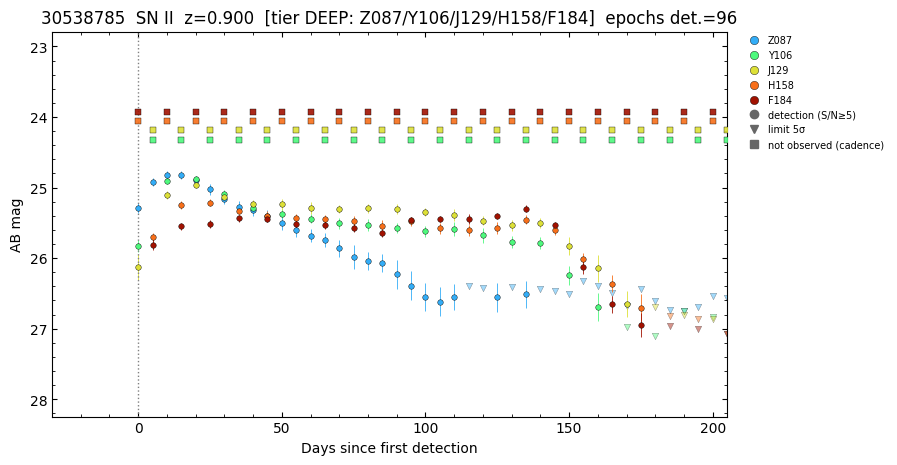

In [4]:
def select_object(transients, select="near_z", target_z=1.0, tol_z=None,
                   min_detected_epochs=3, scan_limit=400,
                   random_choice=True, n_candidates_pool=10, seed=None):
    """Elige el object_id del ejemplo, evaluando sobre las épocas a cadencia real.

    "brightest": el más brillante (alta SNR, error chico).
    "high_z":    el de MAYOR z que todavía se detecta.
    "near_z":    el/los objetos con z más CERCANO a `target_z` que todavía se detectan
                 (>= min_detected_epochs con S/N>=5). Si tol_z se especifica, primero
                 filtra a |z - target_z| <= tol_z; si no hay tol_z, ordena todos por
                 cercanía a target_z.

    random_choice: si True, entre los candidatos válidos más cercanos a target_z
                   (hasta n_candidates_pool) elige uno al azar. Si False, devuelve
                   siempre el más cercano.
    n_candidates_pool: tamaño del pool de candidatos válidos entre los que se sortea.
    seed: semilla opcional para reproducibilidad del sorteo.
    """
    if select == "brightest":
        return int(transients.sort_values("peak_mag_F")["id"].iloc[0])

    if select == "high_z":
        candidates = transients.sort_values("z_CMB", ascending=False)["id"].astype(int).tolist()[:scan_limit]
    elif select == "near_z":
        df = transients.copy()
        df["z_dist"] = (df["z_CMB"] - target_z).abs()
        if tol_z is not None:
            df = df[df["z_dist"] <= tol_z]
        candidates = df.sort_values("z_dist")["id"].astype(int).tolist()[:scan_limit]
    else:
        raise ValueError(f"select desconocido: {select}")

    rng = np.random.default_rng(seed)
    valid = []
    with h5py.File(HDF5_PATH, "r") as hdf5:
        for candidate in candidates:
            photometry = build_photometry(candidate, hdf5=hdf5)
            if int(photometry["detected"].sum()) >= min_detected_epochs:
                valid.append(candidate)
                if not random_choice:
                    return valid[0]
                if len(valid) >= n_candidates_pool:
                    break

    if not valid:
        return candidates[0] if candidates else None

    if random_choice:
        return int(rng.choice(valid))
    return valid[0]


def build_lightcurve_with_error(object_id=None, select="near_z", target_z=1.0, tol_z=None,
                                 plot=True, random_choice=True, n_candidates_pool=10, seed=None):
    """Selecciona un objeto y construye su curva con error a CADENCIA REAL del tier."""
    catalog = pd.read_parquet(CATALOG_PATH)
    catalog["label"] = catalog["gentype"].map(GENTYPE_LABEL)
    with h5py.File(HDF5_PATH, "r") as hdf5:
        present = set(hdf5.keys())
    transients = catalog[(catalog["label"] != "FIXMAG")
                          & catalog["id"].astype(str).isin(present)].copy()

    if object_id is None:
        object_id = select_object(transients, select=select, target_z=target_z, tol_z=tol_z,
                                   random_choice=random_choice, n_candidates_pool=n_candidates_pool,
                                   seed=seed)

    info = catalog[catalog["id"] == object_id].iloc[0]
    photometry = build_photometry(object_id)
    detected_epochs = int(photometry["detected"].sum())
    title = (f"{object_id}  {info['label']}  z={info['z_CMB']:.3f}  "
             f"[tier {TIER.upper()}: {'/'.join(BANDS_BY_WAVELENGTH)}]  "
             f"epochs det.={detected_epochs}")

    if plot:
        figure, ax = plt.subplots(figsize=(10, 5))
        detected_time = photometry.loc[photometry["detected"], "days_since_detection"]
        # Magnitud más brillante MOSTRADA -> ancla la fila de cuadrados de cadencia dentro del ylim.
        if len(detected_time) > 0:
            x_low, x_high = detected_time.min() - 30, detected_time.max() + 30
            visible = photometry[(photometry["days_since_detection"] >= x_low)
                                  & (photometry["days_since_detection"] <= x_high)]
            shown_mag = pd.concat([visible.loc[visible["detected"], "mag_observed"],
                                    visible.loc[~visible["detected"], "mag_limit_5sigma"]])
            reference_magnitude = shown_mag.min()
        else:
            reference_magnitude = None
        plot_lightcurve_with_error(photometry, title=title, ax=ax, reference_magnitude=reference_magnitude)
        if len(detected_time) > 0:
            ax.set_xlim(x_low, x_high)
            margin = max(0.2, 0.5 * (shown_mag.max() - shown_mag.min()))
            # El top incluye el escalón de cadencia más alto (ax._cadence_top_magnitude) con un poco de aire.
            ax.set_ylim(shown_mag.max() + margin,
                        min(shown_mag.min(), ax._cadence_top_magnitude) - margin)  # eje invertido
        # Reserva el margen derecho para la leyenda externa (fuera del área de datos), en vez de tight_layout.
        figure.subplots_adjust(right=0.80)
        figure.savefig("openuniverse_lightcurve_full.pdf", bbox_inches="tight")
        plt.show()

    return photometry, info


photometry, info = build_lightcurve_with_error(object_id=None, select="near_z", target_z=0.9, plot=True)


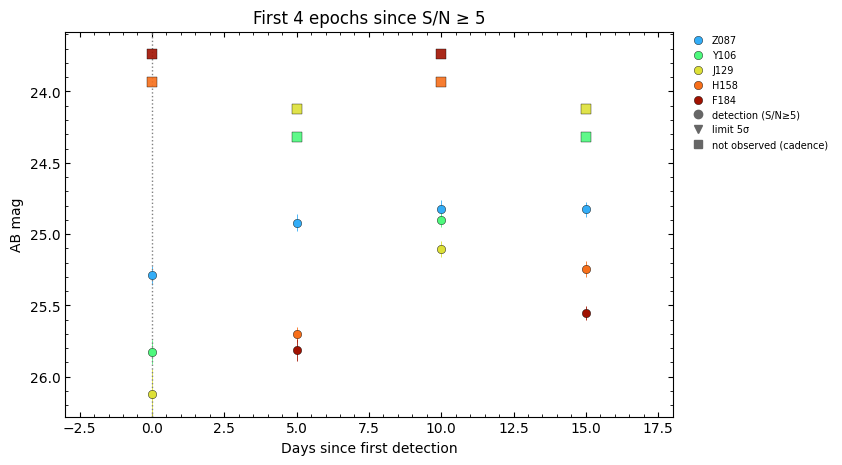

,days_since_detection,band,mag_true,mag_err,snr,detected
77,0.0,J129,26.123861,0.179587,6.045524,True
51,0.0,Y106,25.824501,0.083547,12.995103,True
0,0.0,Z087,25.289181,0.067575,16.066625,True
128,5.0,F184,25.810324,0.077776,13.959377,True
103,5.0,H158,25.703705,0.054429,19.947039,True
1,5.0,Z087,24.919603,0.060706,17.884614,True
78,10.0,J129,25.105907,0.054525,19.911857,True
52,10.0,Y106,24.901066,0.047360,22.924442,True
2,10.0,Z087,24.821186,0.058817,18.458838,True
129,15.0,F184,25.551363,0.048807,22.244596,True


In [5]:
# La selección "primera detección -> N épocas" vive en roman_photometry (misma regla que el pipeline
# y el dataloader). Aquí solo se le agrega el plot con zoom + numeración de épocas, en days_since_detection.
from kilonova.photometry.roman_noise import first_epochs_since_detection as select_first_epochs


def first_epochs_since_detection(photometry, number=4, plot=True):
    """Primeras `number` ÉPOCAS DE OBSERVACIÓN (visitas, cada 5 d) desde la primera detección S/N>=5
    en cualquier banda (regla en roman_photometry.first_epochs_since_detection, eje 'days_since_detection').
    Por construcción la 1ª época cae en days_since_detection=0. Una visita SIN ninguna detección igual
    cuenta como época. El plot hace zoom a esa ventana y sombrea + numera las épocas (#1..#number)."""
    window = select_first_epochs(photometry, number=number, time_column="days_since_detection")
    if len(window) == 0:
        print("Sin detección S/N>=5: el objeto nunca supera el umbral (todo límites superiores).")
        if plot:
            plot_lightcurve_with_error(photometry, title="sin detección S/N>=5")
        return window
    epoch_times = np.sort(window["days_since_detection"].unique())
    if plot:
        figure, ax = plt.subplots(figsize=(9, 5))
        # Zoom ajustado: solo la ventana de las `number` épocas + medio paso de cadencia a cada lado.
        pad = BASE_CADENCE_DAYS * 0.6
        x_low, x_high = epoch_times.min() - pad, epoch_times.max() + pad
        in_window = photometry[(photometry["days_since_detection"] >= x_low)
                               & (photometry["days_since_detection"] <= x_high)]
        shown_mag = pd.concat([in_window.loc[in_window["detected"], "mag_observed"],
                               in_window.loc[~in_window["detected"], "mag_limit_5sigma"]])
        # Magnitud más brillante MOSTRADA en el zoom -> ancla la fila de cuadrados de cadencia.
        reference_magnitude = shown_mag.min() if len(shown_mag) else None
        # marker_scale > 1: pocas épocas en el zoom -> marcadores algo más grandes que el default.
        plot_lightcurve_with_error(photometry, title=f"First {number} epochs since S/N ≥ 5",
                                   ax=ax, marker_scale=1.5, reference_magnitude=reference_magnitude)
        ax.set_xlim(x_low, x_high)
        if len(shown_mag):
            # Margen chico: el zoom tiene pocos puntos, así los datos llenan el eje sin espacio muerto.
            margin = max(0.15, 0.12 * (shown_mag.max() - shown_mag.min()))
            # El top incluye el escalón de cadencia más alto (ax._cadence_top_magnitude) con un poco de aire.
            ax.set_ylim(shown_mag.max() + margin,
                        min(shown_mag.min(), ax._cadence_top_magnitude) - margin)  # eje invertido
        # Reserva el margen derecho para la leyenda externa (fuera del área de datos), en vez de tight_layout.
        figure.subplots_adjust(right=0.80)
        figure.savefig("openuniverse_first_epochs.pdf", bbox_inches="tight")
        plt.show()
    return window


early_window = first_epochs_since_detection(photometry, number=4, plot=True)
early_window[["days_since_detection", "band", "mag_true", "mag_err", "snr", "detected"]]


## Validación final — detection limits vs la tabla de referencia Roman WFI

La tabla oficial de Roman WFI da la **profundidad 5σ por filtro** (S/N=5) a 57 s y 1 hr, medida en
**apertura de 2 px para fuentes puntuales**. Reproducimos esos números con nuestra receta para confirmar
que `zeropoint` + sky + NEA + read noise (eq. 9) son consistentes.

Calculamos **dos** límites por banda:

- **apertura 2 px** — misma definición que la tabla ⇒ debería caer **sobre** los valores de referencia
  (valida zeropoint, sky y read noise);
- **NEA / óptimo** — lo que realmente usa el pipeline ⇒ ~0.2–0.5 mag **más profundo** (la extracción
  óptima siempre gana sobre una apertura fija).

El campo se fija a **ELAIS-N1** (baja zodiacal) para igualar la condición de la tabla, independiente del
campo aleatorio de la corrida. Lectura de resultados: un offset **uniforme** en todas las bandas apunta a
la suposición de zodiacal/fecha; un **outlier** en una sola banda apunta al throughput/thermal de esa banda.


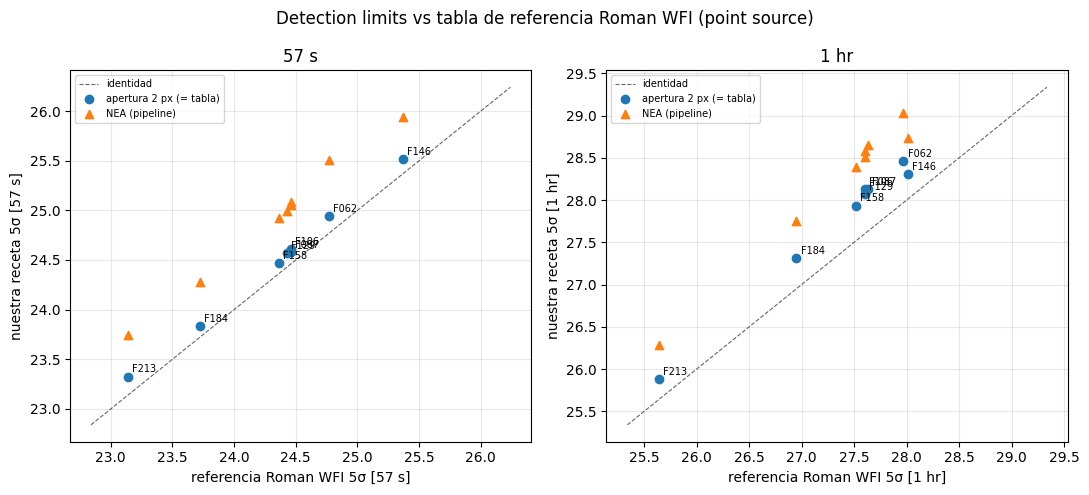

apertura 2px - referencia:  mediana Δ = +0.213 mag (rms 0.158)


,band,ref_57s,ap_57s,d_57s,ref_1hr,ap_1hr,d_1hr,nea_57s,nea_1hr
filter,,,,,,,,,
F062,R062,24.77,24.94,0.17,27.97,28.46,0.49,25.51,29.04
F087,Z087,24.46,24.58,0.12,27.63,28.13,0.50,25.09,28.65
F106,Y106,24.46,24.61,0.15,27.60,28.13,0.53,25.06,28.58
F129,J129,24.43,24.57,0.14,27.60,28.07,0.47,25.00,28.51
F158,H158,24.36,24.47,0.11,27.52,27.94,0.42,24.93,28.39
F184,F184,23.72,23.83,0.11,26.95,27.31,0.36,24.28,27.75
F213,K213,23.14,23.33,0.19,25.64,25.88,0.24,23.74,26.29
F146,W146,25.37,25.51,0.14,28.01,28.30,0.29,25.94,28.73


In [6]:
# Tabla de referencia Roman WFI, 5σ point source (apertura 2 px). filtro_tabla -> (banda galsim, 1hr, 57s).
REFERENCE_5SIGMA_POINT = {
    "F062": ("R062", 27.97, 24.77), "F087": ("Z087", 27.63, 24.46),
    "F106": ("Y106", 27.60, 24.46), "F129": ("J129", 27.60, 24.43),
    "F158": ("H158", 27.52, 24.36), "F184": ("F184", 26.95, 23.72),
    "F213": ("K213", 25.64, 23.14), "F146": ("W146", 28.01, 25.37),
}
VALIDATION_FIELD = galsim.CelestialCoord(HLTDS_FIELD_CENTER["ELAIS-N1"][0] * galsim.degrees,
                                         HLTDS_FIELD_CENTER["ELAIS-N1"][1] * galsim.degrees)
ALL_ROMAN_BANDPASSES = roman.getBandpasses()


def limiting_magnitude_aperture_nea(band, exposure, world_pos, snr=SNR_DETECTION):
    """5σ limiting AB mag de una fuente puntual a `exposure` s en `world_pos`. Devuelve (apertura, nea):
    - apertura: S/N en apertura de 2 px (igual que la tabla de referencia), via el PSF de getPSF;
    - nea     : S/N óptimo pesado por NEA (lo que usa el pipeline), con el NEA de Table 3 (PSF_NEA_PIX).
    K213/W146 no están en Table 3 -> para esas dos se usa la NEA del PSF de galsim como fallback."""
    bandpass = ALL_ROMAN_BANDPASSES[band]
    sky_level = roman.getSkyLevel(bandpass, world_pos=world_pos, exptime=exposure) * roman.pixel_scale ** 2
    read_noise = read_noise_electrons(exposure)
    background_per_pixel = (sky_level + roman.thermal_backgrounds[band] * exposure
                            + roman.dark_current * exposure + read_noise ** 2)

    psf = roman.getPSF(1, band, wavelength=bandpass.effective_wavelength,
                       pupil_bin=8).drawImage(scale=roman.pixel_scale, nx=64, ny=64).array
    psf = psf / psf.sum()
    grid_y, grid_x = np.indices(psf.shape)
    center = (psf.shape[0] - 1) / 2.0
    radius_pixels = np.hypot(grid_x - center, grid_y - center)
    aperture = radius_pixels <= 2.0
    encircled_fraction = psf[aperture].sum()
    aperture_pixels = int(aperture.sum())
    noise_equivalent_area = PSF_NEA_PIX.get(band, 1.0 / np.sum(psf ** 2))

    def limiting_mag(signal_fraction, effective_pixels):
        # SNR = (s·F) / sqrt(s·F + n·bkg) = snr  ->  cuadrática en (s·F)
        background = effective_pixels * background_per_pixel
        collected = 0.5 * (snr ** 2 + np.sqrt(snr ** 4 + 4 * snr ** 2 * background))
        flux_total = collected / signal_fraction
        rate = flux_total / (exposure * collecting_area_cm2())
        return bandpass.zeropoint - 2.5 * np.log10(rate)

    return limiting_mag(encircled_fraction, aperture_pixels), limiting_mag(1.0, noise_equivalent_area)


def build_limit_comparison(world_pos=VALIDATION_FIELD):
    rows = []
    for table_filter, (band, reference_1hr, reference_57s) in REFERENCE_5SIGMA_POINT.items():
        aperture_1hr, nea_1hr = limiting_magnitude_aperture_nea(band, 3600.0, world_pos)
        aperture_57s, nea_57s = limiting_magnitude_aperture_nea(band, 57.0, world_pos)
        rows.append({
            "filter": table_filter, "band": band,
            "ref_57s": reference_57s, "ap_57s": aperture_57s, "d_57s": aperture_57s - reference_57s,
            "ref_1hr": reference_1hr, "ap_1hr": aperture_1hr, "d_1hr": aperture_1hr - reference_1hr,
            "nea_57s": nea_57s, "nea_1hr": nea_1hr,
        })
    return pd.DataFrame(rows).set_index("filter")


def plot_limit_comparison(comparison):
    figure, axes = plt.subplots(1, 2, figsize=(11, 5))
    for axis, label, reference_column, ours_column, nea_column in [
            (axes[0], "57 s", "ref_57s", "ap_57s", "nea_57s"),
            (axes[1], "1 hr", "ref_1hr", "ap_1hr", "nea_1hr")]:
        low = min(comparison[reference_column].min(), comparison[nea_column].min()) - 0.3
        high = max(comparison[reference_column].max(), comparison[nea_column].max()) + 0.3
        axis.plot([low, high], [low, high], "k--", lw=0.8, alpha=0.6, label="identidad")
        axis.scatter(comparison[reference_column], comparison[ours_column],
                     color="tab:blue", zorder=3, label="apertura 2 px (= tabla)")
        axis.scatter(comparison[reference_column], comparison[nea_column],
                     color="tab:orange", marker="^", zorder=3, label="NEA (pipeline)")
        for table_filter, row in comparison.iterrows():
            axis.annotate(table_filter, (row[reference_column], row[ours_column]),
                          fontsize=7, xytext=(3, 3), textcoords="offset points")
        axis.set_xlabel(f"referencia Roman WFI 5σ [{label}]")
        axis.set_ylabel(f"nuestra receta 5σ [{label}]")
        axis.set_title(label)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=7, loc="upper left")
    figure.suptitle("Detection limits vs tabla de referencia Roman WFI (point source)")
    plt.tight_layout()
    plt.show()


limit_comparison = build_limit_comparison()
plot_limit_comparison(limit_comparison)
print(f"apertura 2px - referencia:  mediana Δ = {limit_comparison[['d_57s', 'd_1hr']].stack().median():+.3f} mag "
      f"(rms {limit_comparison[['d_57s', 'd_1hr']].stack().std():.3f})")
limit_comparison.round(2)


## Roman WFI Characteristics Used in Simulations

Características por banda y tier que entran a la receta de ruido de este notebook, derivadas de
`galsim.roman` a **nuestros** tiempos de exposición del HLTDS (`EXPOSURE_TIME_BY_TIER`). Es la tabla
para el paper: documenta cada término del modelo de error y la profundidad alcanzada, de forma trazable.
Las unidades van en el segundo renglón del header (MultiIndex de columnas).

- **exp** — tiempo de exposición total por época del tier (s).
- **PSF_NEA** — número equivalente de píxeles de la PSF (pix), fijo por banda.
- **σ_read** — read noise efectivo (e⁻/pix) a esa exposición (up-the-ramp, eq. 9): baja con `t` hacia el piso de 5 e⁻.
- **σ²_thermal** — tasa de fondo térmico (e⁻/s/pix), `roman.thermal_backgrounds`.
- **σ²_zodi** — tasa de luz zodiacal (e⁻/s/pix), `getSkyLevel` en el campo ELAIS-N1.
- **σ²_dark** — corriente de oscuridad (e⁻/s/pix), `roman.dark_current`.
- **σ_sky** — ruido de fondo acumulado: `sqrt((σ²_zodi+σ²_thermal+σ²_dark)·t)` (e⁻ = ADU con gain 1).
- **ZP_AVG** — zeropoint instrumental en e⁻ totales: `zp_galsim + 2.5·log10(collecting_area) + 2.5·log10(t)` (mag).
- **m_lim_5σ** — magnitud límite AB a S/N = 5 con extracción NEA (la del pipeline), a la exposición del tier (mag).

El error fotométrico de cada época sale de combinar estas columnas con la ecuación CCD
`σ²(F) = F_fuente + NEA·(sky + thermal·t + dark·t + read²)`, más el jitter de zeropoint de 0.15 mag
que absorbe la variación FOV del NEA.


In [7]:
# Tabla de características Roman WFI usadas en nuestras simulaciones: cada término del modelo de ruido más
# la magnitud límite 5sigma, por banda y tier, a los tiempos de exposición del HLTDS (EXPOSURE_TIME_BY_TIER).
# Campo ELAIS-N1 para la zodiacal. Las unidades van en el segundo nivel del header (MultiIndex de columnas).
# delta_zp convierte el zeropoint galsim (fotones/cm^2/s) a e- totales (zeropoint instrumental).
DELTA_ZEROPOINT = 2.5 * np.log10(roman.collecting_area)

# Decimales por columna para el export a LaTeX (to_latex usa 6 por defecto -> ceros de relleno feos).
COLUMN_DECIMALS = {
    ("exp", "s"): 0, ("PSF_NEA", "pix"): 3, ("sigma_read", "e-/pix"): 2,
    ("sigma2_thermal", "e-/s/pix"): 3, ("sigma2_zodi", "e-/s/pix"): 3, ("sigma2_dark", "e-/s/pix"): 3,
    ("sigma_sky", "ADU/pix"): 2, ("ZP_AVG", "mag"): 2, ("m_lim_5sigma", "mag"): 2,
}


def build_characteristics_table(world_pos=VALIDATION_FIELD):
    """Características por (tier, banda) de la receta de ruido de este notebook, derivadas de galsim.roman
    a los tiempos de EXPOSURE_TIME_BY_TIER: NEA, read, thermal, zodi, dark, sky, zeropoint instrumental y
    magnitud límite 5sigma (extracción NEA, la del pipeline)."""
    rows = []
    for tier, exposures in EXPOSURE_TIME_BY_TIER.items():
        for band, exposure in exposures.items():
            bandpass = ALL_ROMAN_BANDPASSES[band]
            zodi_rate = roman.getSkyLevel(bandpass, world_pos=world_pos, exptime=1.0) * roman.pixel_scale ** 2
            thermal_rate = roman.thermal_backgrounds[band]
            dark_rate = roman.dark_current
            sigma_read = read_noise_electrons(exposure)
            noise_equivalent_area = PSF_NEA_PIX[band]
            background_per_pixel = (zodi_rate + thermal_rate + dark_rate) * exposure + sigma_read ** 2
            sigma_sky = np.sqrt((zodi_rate + thermal_rate + dark_rate) * exposure)
            noise_floor_variance = noise_equivalent_area * background_per_pixel
            # Flujo de fuente que da SNR = 5 sobre ese fondo (cuadrática SNR = F/sqrt(F + noise_floor)).
            limiting_flux = 0.5 * (SNR_DETECTION ** 2
                                   + np.sqrt(SNR_DETECTION ** 4 + 4 * SNR_DETECTION ** 2 * noise_floor_variance))
            limiting_magnitude = bandpass.zeropoint - 2.5 * np.log10(limiting_flux / (exposure * roman.collecting_area))
            zeropoint_average = bandpass.zeropoint + DELTA_ZEROPOINT + 2.5 * np.log10(exposure)
            rows.append({
                ("tier", ""): tier, ("filter", ""): band, ("exp", "s"): exposure,
                ("PSF_NEA", "pix"): noise_equivalent_area, ("sigma_read", "e-/pix"): sigma_read,
                ("sigma2_thermal", "e-/s/pix"): thermal_rate, ("sigma2_zodi", "e-/s/pix"): zodi_rate,
                ("sigma2_dark", "e-/s/pix"): dark_rate, ("sigma_sky", "ADU/pix"): sigma_sky,
                ("ZP_AVG", "mag"): zeropoint_average, ("m_lim_5sigma", "mag"): limiting_magnitude,
            })
    table = pd.DataFrame(rows).set_index([("tier", ""), ("filter", "")])
    table.index.names = ["tier", "filter"]
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    return table


def characteristics_to_latex(table):
    """LaTeX listo para el paper: formatea cada columna a su precisión (COLUMN_DECIMALS) para evitar los
    ceros de relleno que mete to_latex por defecto. exp queda como entero."""
    formatted = table.copy()
    for column, decimals in COLUMN_DECIMALS.items():
        formatted[column] = table[column].map(lambda value: f"{value:.{decimals}f}")
    return formatted.to_latex(multirow=True, column_format="ll" + "r" * table.shape[1])


roman_wfi_characteristics = build_characteristics_table()
print(characteristics_to_latex(roman_wfi_characteristics))
roman_wfi_characteristics.round(3)


\begin{tabular}{llrrrrrrrrr}
\toprule
 &  & exp & PSF_NEA & sigma_read & sigma2_thermal & sigma2_zodi & sigma2_dark & sigma_sky & ZP_AVG & m_lim_5sigma \\
 &  & s & pix & e-/pix & e-/s/pix & e-/s/pix & e-/s/pix & ADU/pix & mag & mag \\
tier & filter &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{wide} & R062 & 60 & 5.575 & 12.87 & 0.000 & 0.328 & 0.015 & 4.54 & 31.18 & 25.58 \\
 & Z087 & 85 & 6.695 & 11.28 & 0.000 & 0.299 & 0.015 & 5.17 & 31.22 & 25.63 \\
 & Y106 & 95 & 7.895 & 10.83 & 0.000 & 0.326 & 0.015 & 5.69 & 31.40 & 25.74 \\
 & J129 & 152 & 9.210 & 9.17 & 0.000 & 0.332 & 0.015 & 7.26 & 31.93 & 26.23 \\
 & H158 & 294 & 11.140 & 7.49 & 0.040 & 0.325 & 0.015 & 10.58 & 32.68 & 26.78 \\
\cline{1-11}
\multirow[t]{5}{*}{deep} & Z087 & 193 & 6.695 & 8.48 & 0.000 & 0.299 & 0.015 & 7.79 & 32.12 & 26.59 \\
 & Y106 & 294 & 7.895 & 7.49 & 0.000 & 0.326 & 0.015 & 10.01 & 32.63 & 26.94 \\
 & J129 & 307 & 9.210 & 7.40 & 0.000 & 0.332 & 0.015 & 10.31 & 32.69 & 26.91 \\
 & H158 & 420 

exp PSF_NEA sigma_read sigma2_thermal sigma2_zodi sigma2_dark  \
                  s     pix     e-/pix       e-/s/pix    e-/s/pix    e-/s/pix   
tier filter                                                                     
wide R062      60.0   5.575     12.870           0.00       0.328       0.015   
     Z087      85.0   6.695     11.282           0.00       0.299       0.015   
     Y106      95.0   7.895     10.826           0.00       0.326       0.015   
     J129     152.0   9.210      9.167           0.00       0.332       0.015   
     H158     294.0  11.140      7.491           0.04       0.325       0.015   
deep Z087     193.0   6.695      8.479           0.00       0.299       0.015   
     Y106     294.0   7.895      7.491           0.00       0.326       0.015   
     J129     307.0   9.210      7.404           0.00       0.332       0.015   
     H158     420.0  11.140      6.850           0.04       0.325       0.015   
     F184    1636.0  16.335      5.540           0.17       0.185       0.015   

            sigma_sky  ZP_AVG m_lim_5sigma  
              ADU/pix     mag          mag  
tier filter                                 
wide R062       4.535  31.179       25.577  
     Z087       5.170  31.225       25.627  
     Y106       5.690  31.405       25.738  
     J129       7.258  31.931       26.232  
     H158      10.576  32.682       26.782  
deep Z087       7.790  32.115       26.592  
     Y106      10.010  32.632       26.943  
     J129      10.314  32.695       26.912  
     H158      12.641  33.069       27.063  
     F184      24.609  34.094       27.299

In [8]:
# Figura de DATOS del paper: fila = clase, columna = tier (deep | wide), el MISMO objeto simulado en
# los dos tiers. Los tiers no comparten bandas (deep agrega F184, wide agrega R062) ni profundidad,
# así que mezclarlos panel a panel confundiría clase con tier; por fila, en cambio, es una comparación
# controlada. `in_early_window` se calcula igual (la usa la figura de tokenización) pero no se dibuja.
# Reusa BAND_COLOR / GENTYPE_LABEL / HDF5_PATH / CATALOG_PATH definidos arriba.
from kilonova.photometry.roman_noise import (
    BASE_CADENCE_DAYS, cadence_schedule, epochs_from_first_detection,
)
from kilonova.photometry.spectra import ALL_ROMAN_BANDS
from kilonova.simulation.early_windows import (
    NUMBER_OF_EPOCHS, KN_SEED_OFFSET,
    model_from_hdf5_group, nearest_model_magnitude,
    load_lanl_catalog_metadata, load_lanl_wavelength_grid, build_simulation_time_grids,
    build_kn_models, sample_kn_realizations_on_grid,
)

TIER_COLUMNS = ["deep", "wide"]
CONSTANTS_BY_TIER = {tier: build_tier_constants(tier, field_seed=FIELD_SEED)
                     for tier in TIER_COLUMNS}
# KN (la clase objetivo) + los 4 contaminantes más abundantes, que son casi todo el set de
# entrenamiento. Las clases raras (SLSN-I, TDE, PISN) van a la tabla de censo: con 3-200 objetos,
# un ejemplo individual dice menos que la cuenta.
PANEL_CLASSES = ["KN", "SN II", "SN Ia", "SN Ic", "SN Ib"]
MAX_UPPER_LIMITS_PER_RUN = 2


def sample_full_cadence(object_id, model, constants, base_epochs=None, noise_seed=None,
                        reference_mjd=None):
    """Misma receta de ruido que early_windows.build_window_from_model, pero conservando TODAS las
    visitas en vez de solo la ventana de NUMBER_OF_EPOCHS.

    reference_mjd fija el cero del eje temporal desde afuera: los dos paneles de una fila (mismo
    objeto en deep y en wide) se anclan al epoch de la 1ª detección en deep, así las curvas quedan
    alineadas y se ve que wide detecta más tarde. Si es None se usa la 1ª detección propia y se
    devuelve None cuando el objeto nunca se detecta; con reference_mjd se devuelve igual (un objeto
    que wide no detecta es una fila de triángulos, que es justamente lo que hay que mostrar)."""
    if len(model) == 0:
        return None
    if base_epochs is None:
        window_start = min(band_mjd.min() for band_mjd, _ in model.values())
        window_end = max(band_mjd.max() for band_mjd, _ in model.values())
        base_epochs = np.arange(window_start, window_end + 1e-9, BASE_CADENCE_DAYS)
    base_epochs = np.asarray(base_epochs, dtype=float)
    schedule = cadence_schedule(base_epochs, constants["bands"], constants["anchor_band"])

    jitter_rng, noise_rng = (
        np.random.default_rng(seed) for seed in np.random.SeedSequence(int(noise_seed)).spawn(2)
    )
    jittered_zeropoint = {}
    for band in constants["bands"]:
        if band not in model:
            continue
        band_mjd, _ = model[band]
        observed_mjds = schedule.get(band, np.empty(0))
        epochs = observed_mjds[(observed_mjds >= band_mjd.min()) & (observed_mjds <= band_mjd.max())]
        jitters = jitter_rng.normal(0.0, ZP_JITTER_SIGMA, size=len(epochs))
        for epoch_mjd, jitter in zip(epochs, jitters, strict=True):
            jittered_zeropoint[(band, round(float(epoch_mjd), 6))] = (
                constants["zeropoint"][band] + jitter
            )

    def observation_quantities(band, epoch_mjd, mag_true):
        zeropoint = jittered_zeropoint.get(
            (band, round(float(epoch_mjd), 6)), constants["zeropoint"][band]
        )
        exposure = constants["exposure_time"][band]
        flux_true = source_flux_electrons(mag_true, exposure, zeropoint)
        flux_error = flux_error_electrons(flux_true, constants["noise_floor_variance"][band])
        return zeropoint, exposure, flux_true, flux_error

    detection_mjds = []
    for band in constants["bands"]:
        if band not in model:
            continue
        band_mjd, band_mag = model[band]
        observed_mjds = schedule.get(band, np.empty(0))
        epochs = observed_mjds[(observed_mjds >= band_mjd.min()) & (observed_mjds <= band_mjd.max())]
        if len(epochs) == 0:
            continue
        mag_true_epochs = nearest_model_magnitude(band_mjd, band_mag, epochs)
        for epoch_mjd, mag_true in zip(epochs, mag_true_epochs, strict=True):
            _, _, flux_true, flux_error = observation_quantities(band, epoch_mjd, mag_true)
            if flux_true / flux_error >= SNR_DETECTION:
                detection_mjds.append(epoch_mjd)
    if len(detection_mjds) == 0 and reference_mjd is None:
        return None

    first_detection_mjd = min(detection_mjds) if detection_mjds else np.nan
    origin_mjd = reference_mjd if reference_mjd is not None else first_detection_mjd
    early_window_mjds = (
        set(np.round(epochs_from_first_detection(base_epochs, first_detection_mjd,
                                                 NUMBER_OF_EPOCHS), 6))
        if detection_mjds
        else set()
    )

    rows = []
    for epoch_mjd in base_epochs:
        for band in constants["bands"]:
            observed = band in schedule and np.isclose(schedule[band], epoch_mjd).any()
            mag_true = np.nan
            if band in model:
                band_mjd, band_mag = model[band]
                if band_mjd.min() <= epoch_mjd <= band_mjd.max():
                    mag_true = float(
                        nearest_model_magnitude(band_mjd, band_mag, np.array([epoch_mjd]))[0]
                    )
            row = {
                "object_id": object_id,
                "days_since_detection": float(epoch_mjd - origin_mjd),
                "band": band,
                "observed": bool(observed and np.isfinite(mag_true)),
                "in_early_window": round(float(epoch_mjd), 6) in early_window_mjds,
                "mag_observed": np.nan,
                "mag_err": np.nan,
                "detected": False,
                "mag_limit_5sigma": np.nan,
            }
            if row["observed"]:
                zeropoint, exposure, flux_true, flux_error = observation_quantities(
                    band, epoch_mjd, mag_true
                )
                snr = flux_true / flux_error
                flux_observed = flux_true + noise_rng.normal(0.0, flux_error)
                row["mag_err"] = 1.0857 / snr
                row["detected"] = bool(snr >= SNR_DETECTION)
                row["mag_limit_5sigma"] = limiting_magnitude_5sigma(flux_error, exposure, zeropoint)
                row["mag_observed"] = (
                    zeropoint - 2.5 * np.log10(flux_observed / exposure / collecting_area_cm2())
                    if flux_observed > 0
                    else row["mag_limit_5sigma"]
                )
            rows.append(row)
    photometry = pd.DataFrame(rows)
    photometry.attrs["first_detection_mjd"] = first_detection_mjd
    return photometry


def trim_upper_limits(band_rows):
    """Solo los primeros MAX_UPPER_LIMITS_PER_RUN triángulos de cada racha contigua de no-detecciones:
    una cola larga de límites idénticos no agrega información."""
    band_rows = band_rows.sort_values("days_since_detection")
    is_upper_limit = ~band_rows["detected"].to_numpy()
    position_in_run = np.zeros(len(band_rows), dtype=int)
    counter = 0
    for index, upper_limit in enumerate(is_upper_limit):
        counter = counter + 1 if upper_limit else 0
        position_in_run[index] = counter
    return band_rows[is_upper_limit & (position_in_run <= MAX_UPPER_LIMITS_PER_RUN)]


def cut_after_last_detection(photometry):
    """Recorta la cola del panel: yendo de atrás hacia adelante en el tiempo, las épocas en las que
    NINGUNA banda llega a 5 sigma son todas triángulos y no aportan nada, así que se descartan. El
    panel termina en la última época con al menos una detección. Es una regla por objeto, distinta
    de cut_after_fade, que decide banda por banda."""
    detected = photometry[photometry["detected"]]
    if detected.empty:
        return photometry
    return photometry[photometry["days_since_detection"] <= detected["days_since_detection"].max()]


def cut_after_fade(band_rows):
    """Corta todo lo posterior a la primera racha de MAX_UPPER_LIMITS_PER_RUN no-detecciones después
    del peak de la banda: una vez apagada, los puntos tardíos que vuelven a superar 5 sigma son ruido,
    no señal. Las rachas anteriores al peak se conservan (la subida arranca bajo el límite)."""
    band_rows = band_rows.sort_values("days_since_detection")
    detections = band_rows[band_rows["detected"]]
    if detections.empty:
        return band_rows.iloc[: 2 * MAX_UPPER_LIMITS_PER_RUN]
    peak_position = band_rows.index.get_loc(detections["mag_observed"].idxmin())
    is_upper_limit = ~band_rows["detected"].to_numpy()
    counter = 0
    for position in range(peak_position, len(band_rows)):
        counter = counter + 1 if is_upper_limit[position] else 0
        if counter == MAX_UPPER_LIMITS_PER_RUN:
            return band_rows.iloc[: position + 1]
    return band_rows


def photometry_in_both_tiers(model_6band, base_epochs, noise_seed):
    """El mismo objeto por las dos recetas de tier, ambos anclados a la 1ª detección en deep (la más
    profunda): las dos curvas de la fila quedan en el mismo eje temporal. Devuelve None si deep no
    lo detecta (sin cero de referencia no hay fila que mostrar)."""
    deep = sample_full_cadence(
        "object",
        {band: series for band, series in model_6band.items()
         if band in CONSTANTS_BY_TIER["deep"]["bands"]},
        CONSTANTS_BY_TIER["deep"], base_epochs=base_epochs, noise_seed=noise_seed,
    )
    if deep is None:
        return None
    reference_mjd = deep.attrs["first_detection_mjd"]
    wide = sample_full_cadence(
        "object",
        {band: series for band, series in model_6band.items()
         if band in CONSTANTS_BY_TIER["wide"]["bands"]},
        CONSTANTS_BY_TIER["wide"], base_epochs=base_epochs, noise_seed=noise_seed,
        reference_mjd=reference_mjd,
    )
    return {"deep": deep, "wide": wide}


def select_openuniverse_example(class_catalog, hdf5, target_z, min_detections, scan_limit, rng):
    """Un objeto de la clase con z cercano a target_z, bien detectado en LOS DOS tiers.

    min_detections se exige por tier (no solo en deep): wide es ~1 mag menos profundo, así que un
    objeto elegido solo por deep puede quedar como una fila de triángulos en la columna wide. Pedirlo
    en ambos es lo que fija el z de la fila -- y la fila entera se mueve junta, porque elegir un
    objeto distinto por columna rompería la comparación (dejaría de ser el mismo objeto)."""
    ordered = class_catalog.copy()
    ordered["z_distance"] = (ordered["z_CMB"] - target_z).abs()
    ordered = ordered.sort_values("z_distance").head(scan_limit)
    valid = []
    for _, row in ordered.iterrows():
        # Las 6 bandas Roman: photometry_in_both_tiers recorta después el subset de cada tier.
        # (ALL_ROMAN_BANDS ya excluye K213, que el HLTDS no usa.)
        model_6band = model_from_hdf5_group(hdf5[str(int(row["id"]))], {"bands": ALL_ROMAN_BANDS})
        by_tier = photometry_in_both_tiers(model_6band, None, int(row["id"]))
        if by_tier is None:
            continue
        if all(int(by_tier[tier]["detected"].sum()) >= min_detections for tier in TIER_COLUMNS):
            valid.append((row, by_tier))
            if len(valid) >= 8:
                break
    if not valid:
        return None
    return valid[rng.integers(len(valid))]


def build_kilonova_example(redshift, rng, attempts=40):
    """Una KN de LANL por el MISMO camino que el dataset (kn-kilonova-windows): realizaciones de
    sample_kn_realizations_on_grid en una grilla de un solo z + build_kn_models, con la semilla de
    ruido del pipeline (KN_SEED_OFFSET + noise_id) — la fotometría de las primeras épocas es la
    misma que cae en kn_windows_{tier}.parquet, así el panel valida visualmente la generación.
    La grilla peakea en M_AB ~ -13, así que Roman solo la detecta a z <~ 0.1 y la mayoría de las
    realizaciones dan pocas épocas: se sortean `attempts` y se queda la mejor detectada."""
    paths = load_paths()
    lanl_spectra_path = str(paths.lanl_spectra)
    lanl_catalog = load_lanl_catalog_metadata(lanl_spectra_path)
    wavelength_rest_aa = load_lanl_wavelength_grid(lanl_spectra_path)
    simulation_time_grids = build_simulation_time_grids(lanl_catalog)
    simulation_pool = sorted(simulation_time_grids)

    realizations = sample_kn_realizations_on_grid(
        [redshift], realizations_per_redshift=attempts, simulation_pool=simulation_pool, rng=rng
    )
    kn_models = build_kn_models(realizations, simulation_time_grids, wavelength_rest_aa,
                                lanl_spectra_path, bands=ALL_ROMAN_BANDS)

    best = None
    for _kn_object_id, (model_6band, base_epochs, realization) in kn_models.items():
        by_tier = photometry_in_both_tiers(model_6band, base_epochs,
                                           KN_SEED_OFFSET + realization["noise_id"])
        if by_tier is None:
            continue
        # Se puntúa por el tier PEOR detectado, no por deep: maximizar deep deja paneles wide vacíos.
        detections = min(int(by_tier[tier]["detected"].sum()) for tier in TIER_COLUMNS)
        if best is None or detections > best[0]:
            best = (detections, realization, by_tier)
    if best is None:
        raise RuntimeError(f"no hay KN LANL detectable a z={redshift}")
    return best[1], best[2]

wrote /Users/bhianca/Kilonova/data/openuniverse/paper_class_lightcurves.pdf
wrote /Users/bhianca/Kilonova/data/openuniverse/paper_class_lightcurves_objects.md


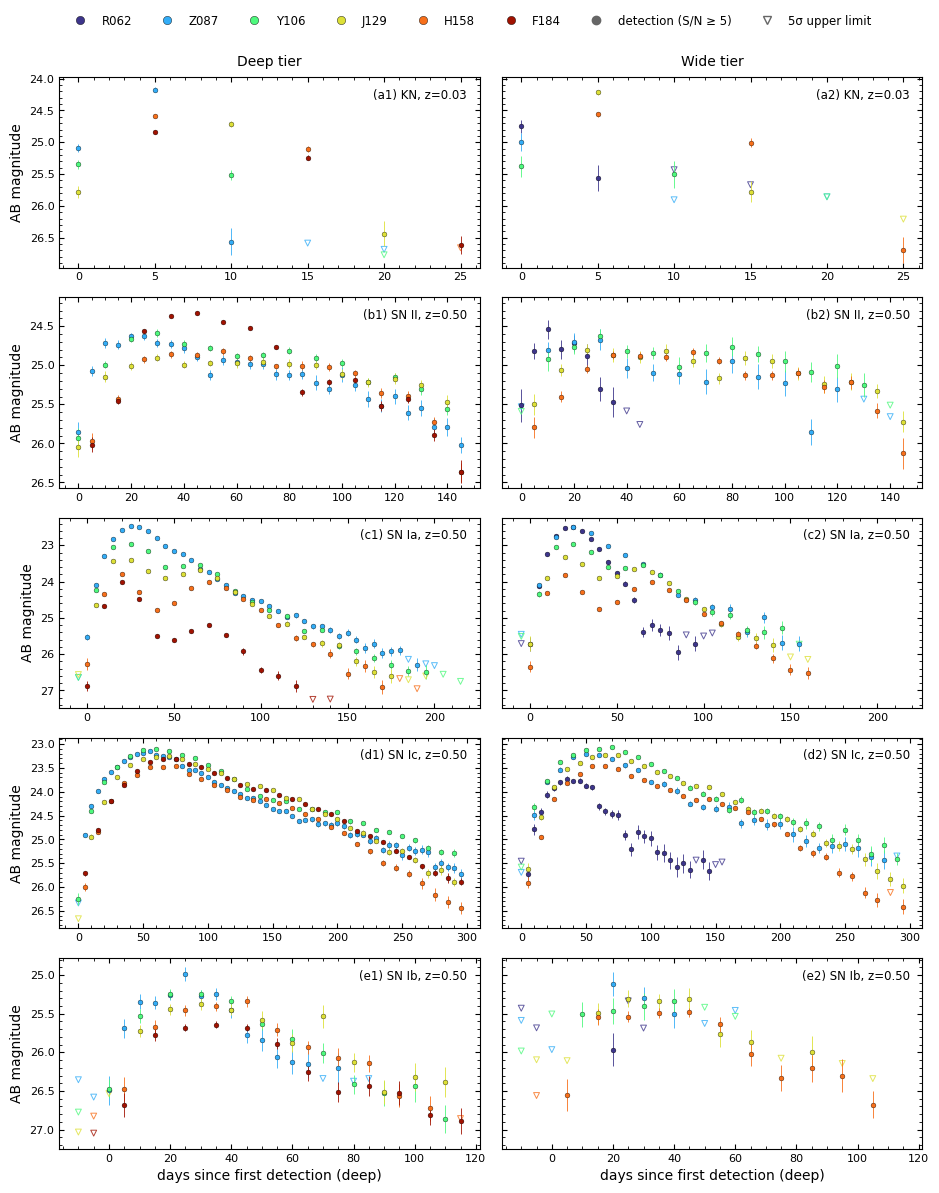

,row,label,object_id,z_CMB,detections_deep,detections_wide
0,a,KN,sim777_angle39,0.0300,13,10
1,b,SN II,30593372,0.5010,90,63
2,c,SN Ia,20144764,0.4977,110,82
3,d,SN Ic,50105728,0.4973,178,145
4,e,SN Ib,40129310,0.5037,61,26


,label,objects
0,SN II,31933
1,SN Ia,10369
2,SN Ic,6984
3,SN Ib,6886
4,SN Iax,5446
5,TDE,192
6,SLSN-I,56
7,PISN-He,5
8,PISN-H,3
9,KN,2


In [9]:
def plot_class_panel(photometry, ax, tier, label):
    """Dibuja un panel y devuelve (mag_min, mag_max, day_min, day_max) de lo mostrado, para que la
    fila comparta escalas entre tiers (es lo que hace visible la diferencia de profundidad)."""
    observed = cut_after_last_detection(photometry[photometry["observed"]])
    bands = CONSTANTS_BY_TIER[tier]["bands"]
    visible = pd.concat(
        [cut_after_fade(observed[observed["band"] == band])
         for band in bands if (observed["band"] == band).any()]
    )
    for band in bands:
        band_rows = cut_after_fade(observed[observed["band"] == band])
        if band_rows.empty:
            continue
        color = BAND_COLOR[band]
        detections = band_rows[band_rows["detected"] & band_rows["mag_observed"].notna()]
        upper_limits = trim_upper_limits(band_rows)
        if len(detections) > 0:
            ax.errorbar(detections["days_since_detection"], detections["mag_observed"],
                        yerr=detections["mag_err"], fmt="o", ms=3.5, color=color, ecolor=color,
                        elinewidth=0.6, capsize=0, mec="k", mew=0.25, zorder=3)
        if len(upper_limits) > 0:
            ax.scatter(upper_limits["days_since_detection"], upper_limits["mag_limit_5sigma"],
                       marker="v", s=18, facecolor="none", edgecolor=color, linewidth=0.7,
                       alpha=0.8, zorder=3)
    ax.text(0.97, 0.94, label, transform=ax.transAxes, ha="right", va="top", fontsize=8.5)
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both", top=True, right=True, labelsize=8)

    shown = pd.concat([
        visible.loc[visible["detected"], "mag_observed"],
        pd.concat([trim_upper_limits(visible[visible["band"] == band])["mag_limit_5sigma"]
                   for band in bands]),
    ]).dropna()
    return (shown.min(), shown.max(),
            visible["days_since_detection"].min(), visible["days_since_detection"].max())


def plot_paper_class_lightcurves(target_z=0.5, kilonova_redshift=0.03, min_detections=10,
                                  scan_limit=250, seed=20260728, plot=True):
    """Figura de DATOS del paper: fila = clase, columna = tier (deep | wide), el MISMO objeto en los
    dos tiers y con el mismo cero temporal (1ª detección en deep). Cada fila comparte ejes, así la
    diferencia entre columnas es solo profundidad y set de filtros: deep llega ~1 mag más hondo y
    agrega F184; wide agrega R062. Círculo = detección S/N>=5 con error 1 sigma, triángulo = límite
    5 sigma. La ventana temprana y los tipos de token van en la figura de tokenización.

    target_z apunta a z~0.5 (y la KN a z~0.03) porque min_detections se exige en AMBOS tiers: a z~1
    wide apenas detecta y esa columna quedaba como una fila de triángulos."""
    catalog = pd.read_parquet(CATALOG_PATH)
    catalog["label"] = catalog["gentype"].map(GENTYPE_LABEL)
    rng = np.random.default_rng(seed)

    realization, kilonova_by_tier = build_kilonova_example(kilonova_redshift, rng)
    rows = [{"label": "KN",
             "object_id": f"sim{realization['simulation_id']}_angle{realization['angle_index']}",
             "z_CMB": kilonova_redshift, "by_tier": kilonova_by_tier}]

    with h5py.File(HDF5_PATH, "r") as hdf5:
        present = set(hdf5.keys())
        catalog = catalog[catalog["id"].astype(str).isin(present)]
        for class_label in PANEL_CLASSES[1:]:
            row, by_tier = select_openuniverse_example(
                catalog[catalog["label"] == class_label], hdf5, target_z, min_detections,
                scan_limit, rng
            )
            rows.append({"label": class_label, "object_id": int(row["id"]),
                         "z_CMB": row["z_CMB"], "by_tier": by_tier})

    summary = pd.DataFrame([
        {"row": letter, "label": entry["label"], "object_id": entry["object_id"],
         "z_CMB": entry["z_CMB"],
         "detections_deep": int(entry["by_tier"]["deep"]["detected"].sum()),
         "detections_wide": int(entry["by_tier"]["wide"]["detected"].sum())}
        for letter, entry in zip("abcde", rows, strict=True)
    ])
    # Censo de todas las clases: para SLSN-I / TDE / PISN (3-200 objetos) la cuenta dice más que un
    # ejemplo individual, y justifica por qué no tienen panel propio.
    census = (catalog[catalog["label"] != "FIXMAG"]
              .groupby("label").size().sort_values(ascending=False)
              .rename("objects").reset_index())

    if plot:
        figure, axes = plt.subplots(5, 2, figsize=(9.5, 12), sharex="row", sharey="row")
        for row_position, (letter, entry) in enumerate(zip("abcde", rows, strict=True)):
            extents = []
            for column_position, tier in enumerate(TIER_COLUMNS):
                ax = axes[row_position, column_position]
                extents.append(plot_class_panel(
                    entry["by_tier"][tier], ax, tier,
                    f"({letter}{column_position + 1}) {entry['label']}, z={entry['z_CMB']:.2f}",
                ))
            magnitude_low = min(extent[0] for extent in extents)
            magnitude_high = max(extent[1] for extent in extents)
            day_low = min(extent[2] for extent in extents)
            day_high = max(extent[3] for extent in extents)
            margin = max(0.2, 0.05 * (magnitude_high - magnitude_low))
            span = day_high - day_low
            for ax in axes[row_position]:
                ax.set_ylim(magnitude_high + margin, magnitude_low - margin)
                ax.set_xlim(day_low - 0.05 * span, day_high + 0.05 * span)
            axes[row_position, 0].set_ylabel("AB magnitude")

        for column_position, tier in enumerate(TIER_COLUMNS):
            axes[0, column_position].set_title(f"{tier.capitalize()} tier", fontsize=10, pad=8)
            axes[-1, column_position].set_xlabel("days since first detection (deep)")

        band_handles = [plt.Line2D([], [], marker="o", ls="", color=BAND_COLOR[band], mec="k",
                                   mew=0.3, label=band) for band in ROMAN_BANDS_BY_WAVELENGTH]
        symbol_handles = [
            plt.Line2D([], [], marker="o", ls="", color="0.4", label="detection (S/N ≥ 5)"),
            plt.Line2D([], [], marker="v", ls="", mfc="none", color="0.4", label="5σ upper limit"),
        ]
        figure.legend(handles=band_handles + symbol_handles, loc="upper center",
                      bbox_to_anchor=(0.5, 0.995), ncol=8, frameon=False, fontsize=8.5)
        figure.tight_layout(rect=(0, 0, 1, 0.965))
        output_path = load_paths().output_dir / "paper_class_lightcurves.pdf"
        figure.savefig(output_path, bbox_inches="tight")
        figure.savefig(output_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
        summary_path = output_path.with_name("paper_class_lightcurves_objects.md")
        summary_path.write_text(summary.to_markdown(index=False) + "\n\n"
                                + census.to_markdown(index=False) + "\n")
        print(f"wrote {output_path}\nwrote {summary_path}")
        plt.show()

    return summary, census


paper_figure_objects, class_census = plot_paper_class_lightcurves(plot=True)
display(paper_figure_objects)
class_census
